### Enhancing Speech Emotion Recognition in Mental Health and Wellness Podcasts Using CRNN(BiLSTM) with Prosody-Aware Attention Mechanism
#### Summary (Proposed Model - RAVDESS Dataset)
This notebook implements an EmotionCRNN model using MFCC features (spectral patterns) and prosodic features (pitch, stress/intensity, speech rate) with convolutional layers, bidirectional LSTM, and prosody-aware attention. Evaluated on RAVDESS (8 emotions), the model achieves 85% accuracy with macro-averaged precision of 0.85, recall of 0.84, and F1-score of 0.84.

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import librosa
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from tqdm import tqdm

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Data Loading and Preprocessing

In [2]:
def extract_prosodic_features(file_path):
    try:
        y, sr = librosa.load(file_path, duration=3)
        
        if len(y) < sr * 3:
            y = np.pad(y, (0, sr * 3 - len(y)))
        else:
            y = y[:sr * 3]
        
        hop_length = 512
        frame_length = 2048
        
        # Extract pitch (F0)
        f0, voiced_flag, voiced_probs = librosa.pyin(
            y, 
            fmin=librosa.note_to_hz('C2'), 
            fmax=librosa.note_to_hz('C7'),
            sr=sr,
            hop_length=hop_length
        )
        f0 = np.nan_to_num(f0)
        
        if len(f0) > 1:
            pitch_var = np.abs(np.diff(f0, axis=0))
            pitch_var = np.pad(pitch_var, (0, 1), mode='edge')
        else:
            pitch_var = np.zeros_like(f0)
        
        # Extract intensity (RMS)
        rms = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length)[0]
        
        if len(rms) > 1:
            energy_var = np.abs(np.diff(rms, axis=0))
            energy_var = np.pad(energy_var, (0, 1), mode='edge')
        else:
            energy_var = np.zeros_like(rms)
        
        # Extract speech rate
        onset_env = librosa.onset.onset_strength(y=y, sr=sr, hop_length=hop_length)
        tempo, beats = librosa.beat.beat_track(onset_envelope=onset_env, sr=sr, hop_length=hop_length)
        
        tempo_frames = np.zeros_like(onset_env)
        if len(beats) > 0:
            tempo_frames[beats] = 1.0
        
        if len(onset_env) > 1:
            rate_var = np.abs(np.diff(onset_env, axis=0))
            rate_var = np.pad(rate_var, (0, 1), mode='edge')
        else:
            rate_var = np.zeros_like(onset_env)
        
        # Extract jitter (pitch perturbation)
        jitter = np.zeros_like(f0)
        voiced_indices = np.where(f0 > 0)[0]
        if len(voiced_indices) > 1:
            for i in range(len(voiced_indices) - 1):
                idx = voiced_indices[i]
                next_idx = voiced_indices[i + 1]
                if f0[idx] > 0 and f0[next_idx] > 0:
                    jitter[idx] = np.abs(f0[next_idx] - f0[idx]) / (f0[idx] + 1e-8)
        
        
        shimmer = np.zeros_like(rms)
        if len(rms) > 1:
            for i in range(len(rms) - 1):
                if rms[i] > 0:
                    shimmer[i] = np.abs(rms[i+1] - rms[i]) / (rms[i] + 1e-8)
        
        min_length = min(len(f0), len(pitch_var), len(jitter), len(rms), 
                        len(energy_var), len(shimmer), len(rate_var), len(tempo_frames))
        
        
        formants = np.zeros((3, min_length))
        n_frames = min_length
        frame_samples = len(y) // n_frames if n_frames > 0 else len(y)
        
        for i in range(n_frames):
            start_idx = i * frame_samples
            end_idx = min(start_idx + frame_samples, len(y))
            frame = y[start_idx:end_idx]
            
            if len(frame) > 16:
                try:
                    pre_emphasized = np.append(frame[0], frame[1:] - 0.97 * frame[:-1])
                    a = librosa.lpc(pre_emphasized, order=12)
                    roots = np.roots(a)
                    roots = roots[np.imag(roots) >= 0]
                    angles = np.arctan2(np.imag(roots), np.real(roots))
                    freqs = angles * (sr / (2 * np.pi))
                    freqs = sorted(freqs[freqs > 90])
                    
                    for j in range(min(3, len(freqs))):
                        formants[j, i] = freqs[j]
                except:
                    pass
        
        # Truncate features
        f0 = f0[:min_length]
        pitch_var = pitch_var[:min_length]
        jitter = jitter[:min_length]
        rms = rms[:min_length]
        energy_var = energy_var[:min_length]
        shimmer = shimmer[:min_length]
        rate_var = rate_var[:min_length]
        tempo_frames = tempo_frames[:min_length]
        
        # Stack prosodic features
        prosodic_features = np.vstack([
            f0, pitch_var, jitter, rms, energy_var, shimmer, 
            rate_var, tempo_frames, formants[0], formants[1], formants[2]
        ])
        
        assert prosodic_features.shape[0] == 11, f"Expected features, got {prosodic_features.shape[0]}"
        
        # Normalize features
        for i in range(prosodic_features.shape[0]):
            if np.any(prosodic_features[i]):
                prosodic_features[i] = (prosodic_features[i] - np.mean(prosodic_features[i])) / (np.std(prosodic_features[i]) + 1e-8)
        
        return prosodic_features
    except Exception as e:
        print(f"Error processing {file_path}: {str(e)}")
        return None

def load_ravdess_data(data_path):
    data = []
    for actor in os.listdir(data_path):
        if actor.startswith('Actor'):
            actor_path = os.path.join(data_path, actor)
            for filename in os.listdir(actor_path):
                file_path = os.path.join(actor_path, filename)
                # Parse filename for labels (format: 03-01-01-01-01-01-01.wav)
                parts = filename.split('-')
                emotion = int(parts[2]) - 1  
                data.append({
                    'path': file_path,
                    'emotion': emotion,
                    'actor': actor
                })
    return pd.DataFrame(data)

def extract_mfcc(file_path, n_mfcc=40):
    try:
        # Load audio file
        y, sr = librosa.load(file_path, duration=3)
        
        # Ensure consistent length
        if len(y) < sr * 3:
            y = np.pad(y, (0, sr * 3 - len(y)))
        else:
            y = y[:sr * 3]
        
        # Extract MFCC features
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        
       
        mfcc_delta = librosa.feature.delta(mfcc, order=1)
        mfcc_delta2 = librosa.feature.delta(mfcc, order=2)
        
        
        mfcc_combined = np.vstack([mfcc, mfcc_delta, mfcc_delta2])
        
        
        assert mfcc_combined.shape[0] == 120, f"Expected 120 MFCC features, got {mfcc_combined.shape[0]}"
        
        return mfcc_combined
    except Exception as e:
        print(f"Error processing {file_path}: {str(e)}")
        return None

# Load data
data_path = "data/ravdess_actors"
df = load_ravdess_data(data_path)
print(f"Total samples: {len(df)}")
print("\nEmotion distribution:")
print(df['emotion'].value_counts())

Total samples: 1440

Emotion distribution:
emotion
1    192
2    192
3    192
4    192
6    192
5    192
7    192
0     96
Name: count, dtype: int64


In [3]:
# Extract features
print("Extracting MFCC and prosodic features...")
X_mfcc = []
X_prosody = []
y = []

for _, row in tqdm(df.iterrows(), total=len(df)):
    mfcc = extract_mfcc(row['path'])
    prosody = extract_prosodic_features(row['path'])
    
    if mfcc is not None and prosody is not None:
        mfcc = mfcc.T
        prosody = prosody.T
        
        min_length = min(mfcc.shape[0], prosody.shape[0])
        mfcc = mfcc[:min_length]
        prosody = prosody[:min_length]
        
        X_mfcc.append(mfcc)
        X_prosody.append(prosody)
        y.append(row['emotion'])

X_mfcc = np.array(X_mfcc)
X_prosody = np.array(X_prosody)
y = np.array(y)

print(f"MFCC features shape: {X_mfcc.shape}")
print(f"Prosodic features shape: {X_prosody.shape}")
print(f"Labels shape: {y.shape}")

# Split and convert to tensors
X_mfcc_train, X_mfcc_test, X_prosody_train, X_prosody_test, y_train, y_test = train_test_split(
    X_mfcc, X_prosody, y, test_size=0.2, random_state=42
)

X_mfcc_train = torch.FloatTensor(X_mfcc_train).transpose(1, 2)
X_mfcc_test = torch.FloatTensor(X_mfcc_test).transpose(1, 2)
X_prosody_train = torch.FloatTensor(X_prosody_train).transpose(1, 2)
X_prosody_test = torch.FloatTensor(X_prosody_test).transpose(1, 2)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

print("\nTraining set shapes:")
print(f"MFCC: {X_mfcc_train.shape}")
print(f"Prosody: {X_prosody_train.shape}")
print(f"Test set shapes:")
print(f"MFCC: {X_mfcc_test.shape}")
print(f"Prosody: {X_prosody_test.shape}")
print(f"Number of training samples: {len(y_train)}")
print(f"Number of test samples: {len(y_test)}")

# Create custom dataset class for multiple inputs
class MultiModalDataset(Dataset):
    def __init__(self, mfcc_features, prosody_features, labels):
        self.mfcc_features = mfcc_features
        self.prosody_features = prosody_features
        self.labels = labels
        
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return (self.mfcc_features[idx], self.prosody_features[idx]), self.labels[idx]

# Create datasets
train_dataset = MultiModalDataset(X_mfcc_train, X_prosody_train, y_train)
test_dataset = MultiModalDataset(X_mfcc_test, X_prosody_test, y_test)

Extracting MFCC and prosodic features...


100%|██████████| 1440/1440 [15:47<00:00,  1.52it/s]

MFCC features shape: (1440, 130, 120)
Prosodic features shape: (1440, 130, 11)
Labels shape: (1440,)

Training set shapes:
MFCC: torch.Size([1152, 120, 130])
Prosody: torch.Size([1152, 11, 130])
Test set shapes:
MFCC: torch.Size([288, 120, 130])
Prosody: torch.Size([288, 11, 130])
Number of training samples: 1152
Number of test samples: 288


## Model Architecture

The EmotionCRNN uses a dual-branch architecture to process complementary audio features:

**MFCC Branch** (120 features: 40 MFCC + 40 Delta + 40 Delta-Delta)
- Two convolutional blocks (64→128 channels) with batch normalization, ReLU, max pooling, and dropout
- Captures spectral patterns and temporal dynamics of speech

**Prosody Branch** (11 features: pitch, stress/intensity, and speech rate)
- Two convolutional blocks (32→64 channels) with similar architecture
- Captures emotional prosodic patterns

**Fusion and Sequential Processing**
- Features concatenated (192 channels) and processed through shared convolutional layers (256 channels)
- Two **Bidirectional LSTM (BiLSTM)** layers (128 units each) capture long-term temporal dependencies
- Prosody-aware attention mechanism weights BiLSTM outputs using prosody features
- Fully connected layers (256→128→8) for final emotion classification

The model combines local spectral-temporal patterns (CNNs), long-range dependencies (LSTMs), and emotion-specific prosodic cues (attention) for robust speech emotion recognition.

In [4]:
class EmotionCRNN(nn.Module):
    def __init__(self, num_classes=8):
        super(EmotionCRNN, self).__init__()
        
        # MFCC branch 
        self.mfcc_conv1 = nn.Sequential(
            nn.Conv1d(120, 64, kernel_size=3, padding='same'),  
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=3, padding='same'),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.2)
        )
        
        self.mfcc_conv2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding='same'),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Conv1d(128, 128, kernel_size=3, padding='same'),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.3)
        )
        
        # Prosody branch
        self.prosody_conv1 = nn.Sequential(
            nn.Conv1d(11, 32, kernel_size=3, padding='same'),  
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Conv1d(32, 32, kernel_size=3, padding='same'),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.2)
        )
        
        self.prosody_conv2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=3, padding='same'),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=3, padding='same'),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.3)
        )
        
        # Shared layers (128 + 64 = 192 channels after concatenation)
        self.shared_conv = nn.Sequential(
            nn.Conv1d(192, 256, kernel_size=3, padding='same'),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Conv1d(256, 256, kernel_size=3, padding='same'),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.4)
        )
        
        # Bidirectional LSTM layers
        self.lstm1 = nn.LSTM(256, 128, bidirectional=True, batch_first=True)
        self.lstm_dropout1 = nn.Dropout(0.4)
        self.lstm2 = nn.LSTM(256, 128, bidirectional=True, batch_first=True)
        self.lstm_dropout2 = nn.Dropout(0.4)
        
        # Prosody-aware attention components
        self.prosody_projection = nn.Linear(64, 256)  # Project prosody to match LSTM size
        self.query_transform = nn.Linear(256, 256)
        self.key_transform = nn.Linear(256, 256)
        self.value_transform = nn.Linear(256, 256)
        
        # Attention combination
        self.attention_combine = nn.Sequential(
            nn.Linear(256, 256),
            nn.Sigmoid()
        )
        
        # Fully connected layers
        self.fc1 = nn.Linear(256, 128)
        self.fc_bn = nn.BatchNorm1d(128)
        self.fc_relu = nn.ReLU()
        self.fc_dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, num_classes)
        
    def prosody_aware_attention(self, lstm_output, prosody_features):
        # Ensure prosody_features have the same sequence length as lstm_output
        if prosody_features.size(1) != lstm_output.size(1):
            prosody_features = torch.nn.functional.interpolate(
                prosody_features.transpose(1, 2),
                size=lstm_output.size(1),
                mode='linear'
            ).transpose(1, 2)
        
        # Project prosody features to match LSTM dimension
        prosody_proj = self.prosody_projection(prosody_features)
        
        # Compute attention scores using scaled dot-product attention
        queries = self.query_transform(lstm_output)
        keys = self.key_transform(prosody_proj)
        values = self.value_transform(lstm_output)
        
        # Scaled dot-product attention
        attention_scores = torch.matmul(queries, keys.transpose(-2, -1))
        attention_scores = attention_scores / (256 ** 0.5)  # Scale by sqrt(d_k)
        attention_weights = torch.softmax(attention_scores, dim=-1)
        
        # Apply attention weights
        context = torch.matmul(attention_weights, values)
        
        # Gating mechanism
        gate = self.attention_combine(context)
        gated_context = gate * context + (1 - gate) * lstm_output
        
        # Global average pooling
        pooled = torch.mean(gated_context, dim=1)
        
        return pooled, attention_weights
        
    def forward(self, inputs):
        mfcc_input, prosody_input = inputs
        batch_size = mfcc_input.size(0)
        
        # Process MFCC branch
        mfcc = self.mfcc_conv1(mfcc_input)
        mfcc = self.mfcc_conv2(mfcc)
        
        # Process Prosody branch
        prosody = self.prosody_conv1(prosody_input)
        prosody = self.prosody_conv2(prosody)
        
        # Save prosody features for attention
        prosody_features = prosody.transpose(1, 2)
        
        # Concatenate features along the channel dimension
        x = torch.cat([mfcc, prosody], dim=1)
        
        # Shared processing
        x = self.shared_conv(x)
        
        # Prepare for LSTM (B, C, T) -> (B, T, C)
        x = x.transpose(1, 2)
        
        # Bidirectional LSTM layers
        lstm_out1, _ = self.lstm1(x)
        lstm_out1 = self.lstm_dropout1(lstm_out1)
        lstm_out2, _ = self.lstm2(lstm_out1)
        lstm_out2 = self.lstm_dropout2(lstm_out2)
        
        # Apply prosody-aware attention
        attended, _ = self.prosody_aware_attention(lstm_out2, prosody_features)
        
        # Fully connected layers
        x = self.fc1(attended)
        x = self.fc_bn(x)
        x = self.fc_relu(x)
        x = self.fc_dropout(x)
        x = self.fc2(x)
        
        return x

# Create the model instance
model = EmotionCRNN().to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

# Mixup criterion function
def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

print(model)

EmotionCRNN(
  (mfcc_conv1): Sequential(
    (0): Conv1d(120, 64, kernel_size=(3,), stride=(1,), padding=same)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=same)
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.2, inplace=False)
  )
  (mfcc_conv2): Sequential(
    (0): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=same)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=same)
    (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p

## Training Configuration
The model uses the following training parameters:
- Batch size: 16
- Number of epochs: 200
- Learning rate: 0.00005
- Optimizer: RMSprop
- Loss function: CrossEntropyLoss
- Dropout rate: 0.1

In [5]:
# Training parameters
import math

num_epochs = 300
batch_size = 24

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

# Learning rate scheduler with warmup
def get_cosine_schedule_with_warmup(optimizer, num_warmup_steps, num_training_steps, num_cycles=0.5):
    def lr_lambda(current_step):
        if current_step < num_warmup_steps:
            return float(current_step) / float(max(1, num_warmup_steps))
        progress = float(current_step - num_warmup_steps) / float(max(1, num_training_steps - num_warmup_steps))
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# Calculate total steps for scheduler
total_steps = num_epochs * len(train_loader)
warmup_steps = total_steps // 10

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

def mixup_data(x, y, epoch, num_epochs, alpha_start=0.2, alpha_end=0.4):
    alpha = alpha_start + (alpha_end - alpha_start) * (epoch / num_epochs)
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x[0].size()[0]
    index = torch.randperm(batch_size).to(device)

    mixed_x = (
        lam * x[0] + (1 - lam) * x[0][index],
        lam * x[1] + (1 - lam) * x[1][index]
    )
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

# Training loop
train_losses = []
val_losses = []
test_accuracies = []
best_accuracy = 0
best_model_state = None

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    
    # Training phase
    with tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}') as pbar:
        for (mfcc_x, prosody_x), batch_y in pbar:
            mfcc_x = mfcc_x.to(device)
            prosody_x = prosody_x.to(device)
            batch_y = batch_y.to(device)
            
            
            mixed_X, y_a, y_b, lam = mixup_data((mfcc_x, prosody_x), batch_y, epoch, num_epochs)
            
            optimizer.zero_grad()
            outputs = model(mixed_X)
            
            loss = mixup_criterion(criterion, outputs, y_a, y_b, lam)
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            scheduler.step()
            
            total_loss += loss.item()
            pbar.set_postfix({'loss': loss.item()})
    
    # Validation phase
    model.eval()
    correct = 0
    total = 0
    all_predictions = []
    all_targets = []
    total_val_loss = 0
    
    with torch.no_grad():
        for (mfcc_x, prosody_x), batch_y in test_loader:
            mfcc_x = mfcc_x.to(device)
            prosody_x = prosody_x.to(device)
            batch_y = batch_y.to(device)
            
            outputs = model((mfcc_x, prosody_x))
            
            val_loss = criterion(outputs, batch_y)
            total_val_loss += val_loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()
            
            all_predictions.extend(predicted.cpu().numpy())
            all_targets.extend(batch_y.cpu().numpy())
    
    accuracy = 100 * correct / total
    avg_train_loss = total_loss / len(train_loader)
    avg_val_loss = total_val_loss / len(test_loader)
    
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    test_accuracies.append(accuracy)
    
    # Save best model
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model_state = model.state_dict().copy()
        epoch_predictions = all_predictions
        epoch_targets = all_targets
        
        # Save model checkpoint with absolute path
        # c:\Users\LENOVO-Pc\OneDrive\Documents\THESIS-SER\new model\best_multimodal_model.pth
        save_path = r'C:\Users\Ezeniel Cuenca\Documents\GitHub\THESIS-SER\new model\best_multimodal_model.pth'
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'accuracy': accuracy,
        }, save_path)
        print(f'Model saved to {save_path}')
    
    print(f'Epoch [{epoch+1}/{num_epochs}]')
    print(f'Training Loss: {avg_train_loss:.4f}')
    print(f'Validation Loss: {avg_val_loss:.4f}')
    print(f'Test Accuracy: {accuracy:.2f}%')
    print(f'Best Accuracy: {best_accuracy:.2f}%')
    print('-' * 50)

# Load best model
model.load_state_dict(best_model_state)
print(f'\nFinal Best Accuracy: {best_accuracy:.2f}%')

Epoch 1/300: 100%|██████████| 48/48 [00:02<00:00, 22.74it/s, loss=2.15]


Model saved to C:\Users\Ezeniel Cuenca\Documents\GitHub\THESIS-SER\new model\best_multimodal_model.pth
Epoch [1/300]
Training Loss: 2.1996
Validation Loss: 2.0747
Test Accuracy: 14.58%
Best Accuracy: 14.58%
--------------------------------------------------


Epoch 2/300: 100%|██████████| 48/48 [00:00<00:00, 74.08it/s, loss=2.2] 


Model saved to C:\Users\Ezeniel Cuenca\Documents\GitHub\THESIS-SER\new model\best_multimodal_model.pth
Epoch [2/300]
Training Loss: 2.1231
Validation Loss: 1.8783
Test Accuracy: 28.47%
Best Accuracy: 28.47%
--------------------------------------------------


Epoch 3/300: 100%|██████████| 48/48 [00:00<00:00, 77.63it/s, loss=2.07]


...

Epoch [298/300]
Training Loss: 0.5199
Validation Loss: 0.5371
Test Accuracy: 86.46%
Best Accuracy: 87.85%
--------------------------------------------------


Epoch 299/300: 100%|██████████| 48/48 [00:00<00:00, 80.35it/s, loss=0.74]  


Epoch [299/300]
Training Loss: 0.5913
Validation Loss: 0.5610
Test Accuracy: 85.07%
Best Accuracy: 87.85%
--------------------------------------------------


Epoch 300/300: 100%|██████████| 48/48 [00:00<00:00, 80.86it/s, loss=1.2]   


Epoch [300/300]
Training Loss: 0.4991
Validation Loss: 0.5413
Test Accuracy: 86.11%
Best Accuracy: 87.85%
--------------------------------------------------

Final Best Accuracy: 87.85%


## Training Progress and Metrics

The training progress shows:
- Loss: The training loss per epoch (lower is better)
- Test Accuracy: Overall accuracy on the test set
- Detailed classification report every 10 epochs including:
  - Precision: Ratio of true positives to all predicted positives
  - Recall: Ratio of true positives to all actual positives
  - F1-score: Harmonic mean of precision and recall
  - Support: Number of samples for each class

In [6]:
# Generate final classification report
emotion_labels = ['neutral', 'calm', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']

print('Final Classification Report:')
print(classification_report(epoch_targets, epoch_predictions, target_names=emotion_labels))

Final Classification Report:
              precision    recall  f1-score   support

     neutral       1.00      0.80      0.89        20
        calm       0.86      0.98      0.91        44
       happy       0.76      0.91      0.83        34
         sad       0.82      0.82      0.82        39
       angry       0.97      0.88      0.93        42
     fearful       0.89      0.75      0.81        32
     disgust       0.89      0.97      0.93        32
   surprised       0.93      0.87      0.90        45

    accuracy                           0.88       288
   macro avg       0.89      0.87      0.88       288
weighted avg       0.89      0.88      0.88       288



## Classification Report

The classification report shows the model's performance for each emotion:
- **Precision**: How many of the predictions for each emotion were correct
- **Recall**: How many of the actual instances of each emotion were correctly identified
- **F1-score**: The harmonic mean of precision and recall
- **Support**: Number of samples for each emotion in the test set

A score closer to 1.0 indicates better performance.

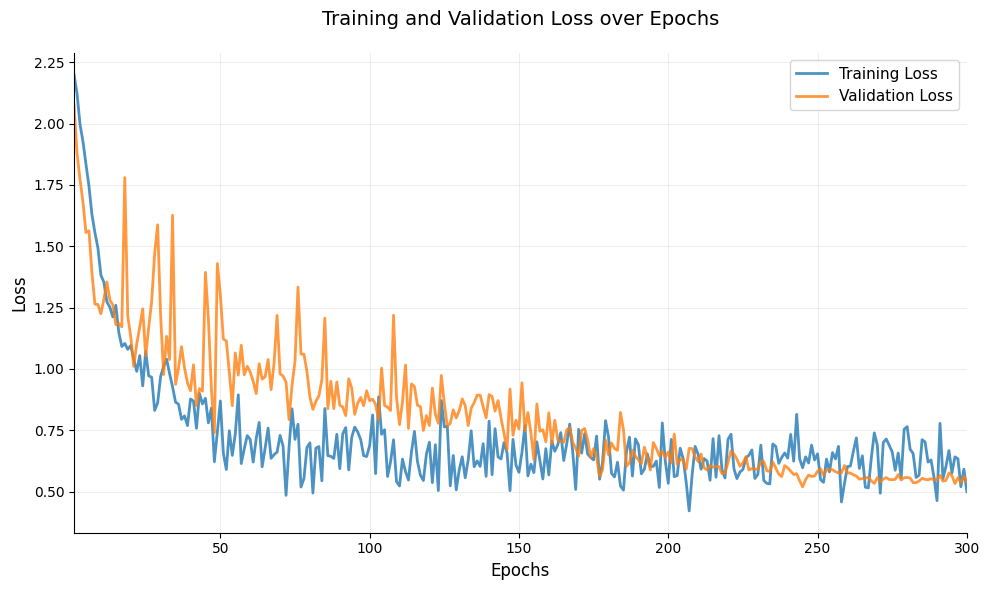


Final Results:
Best Validation Accuracy: 87.85%
Final Training Loss: 0.4991
Final Validation Loss: 0.5413


In [7]:
# Plot training and validation loss over epochs
plt.figure(figsize=(10, 6))

# Plot both training and validation loss in one plot
epochs_range = range(1, len(train_losses) + 1)
plt.plot(epochs_range, train_losses, label='Training Loss', color='#1f77b4', alpha=0.8, linewidth=2, markersize=3)
plt.plot(epochs_range, val_losses, label='Validation Loss', color='#ff7f0e', alpha=0.8, linewidth=2, markersize=3)

plt.title('Training and Validation Loss over Epochs', fontsize=14, pad=20)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

# Set axis limits and ticks
plt.xlim(1, len(train_losses))
plt.gca().tick_params(labelsize=10)

# Style the plot
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_linewidth(0.8)
plt.gca().spines['bottom'].set_linewidth(0.8)

plt.tight_layout()
plt.show()

# Print final metrics
print(f"\nFinal Results:")
print(f"Best Validation Accuracy: {max(test_accuracies):.2f}%")
print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Final Validation Loss: {val_losses[-1]:.4f}")

## Confusion Matrix

The confusion matrix shows:
- Rows: True emotions
- Columns: Predicted emotions
- Numbers: Count of predictions
- Diagonal: Correct predictions
- Off-diagonal: Misclassifications

This helps identify which emotions are commonly confused with each other.

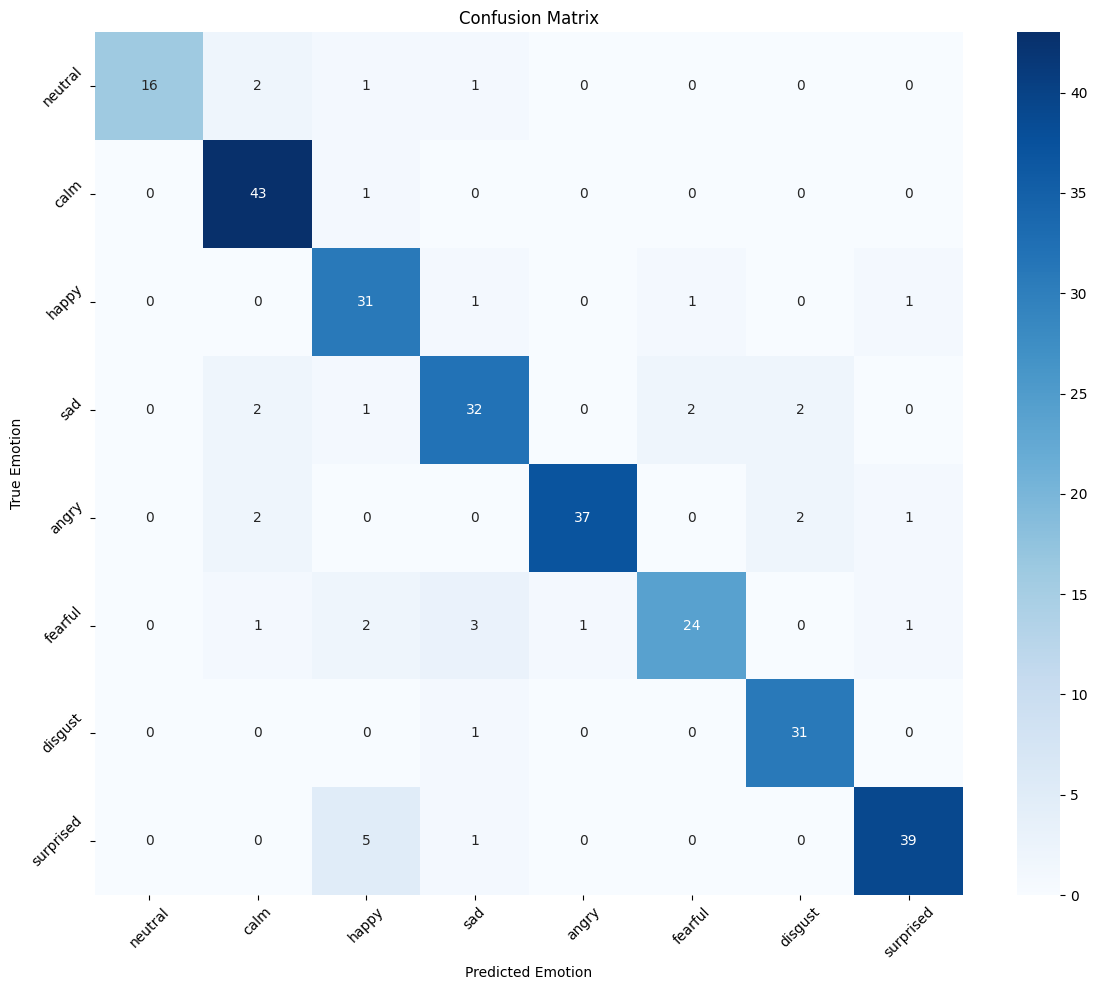


Confusion Matrix Analysis:
Total Correct Predictions: 253
Total Samples: 288
Overall Accuracy: 87.85%

Per-class Accuracy:
neutral: 80.00%
calm: 97.73%
happy: 91.18%
sad: 82.05%
angry: 88.10%
fearful: 75.00%
disgust: 96.88%
surprised: 86.67%

FALSE POSITIVES (FP) AND FALSE NEGATIVES (FN) ANALYSIS

Emotion      True Pos   False Pos  False Neg  True Neg   Precision  Recall    
--------------------------------------------------------------------------------
neutral      16         0          4          268        1.000      0.800     
calm         43         7          1          237        0.860      0.977     
happy        31         10         3          244        0.756      0.912     
sad          32         7          7          242        0.821      0.821     
angry        37         1          5          245        0.974      0.881     
fearful      24         3          8          253        0.889      0.750     
disgust      31         4          1          252        0.886    

In [8]:
# Create and plot confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(epoch_targets, epoch_predictions)

# Create confusion matrix plot
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_labels,
            yticklabels=emotion_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Emotion')
plt.ylabel('True Emotion')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

# Print overall metrics
total_correct = np.sum(np.diag(cm))
total_samples = np.sum(cm)
print(f"\nConfusion Matrix Analysis:")
print(f"Total Correct Predictions: {total_correct}")
print(f"Total Samples: {total_samples}")
print(f"Overall Accuracy: {100 * total_correct / total_samples:.2f}%")

# Calculate per-class accuracy
print("\nPer-class Accuracy:")
for i, emotion in enumerate(emotion_labels):
    class_correct = cm[i, i]
    class_total = np.sum(cm[i, :])
    if class_total > 0:
        class_accuracy = 100 * class_correct / class_total
        print(f"{emotion}: {class_accuracy:.2f}%")

# Calculate False Positives (FP) and False Negatives (FN) per class
print("\n" + "="*80)
print("FALSE POSITIVES (FP) AND FALSE NEGATIVES (FN) ANALYSIS")
print("="*80)

print(f"\n{'Emotion':<12} {'True Pos':<10} {'False Pos':<10} {'False Neg':<10} {'True Neg':<10} {'Precision':<10} {'Recall':<10}")
print("-"*80)

for i, emotion in enumerate(emotion_labels):
    # True Positives (TP): Diagonal elements
    tp = cm[i, i]
    
    # False Positives (FP): Sum of column i excluding diagonal
    fp = np.sum(cm[:, i]) - cm[i, i]
    
    # False Negatives (FN): Sum of row i excluding diagonal
    fn = np.sum(cm[i, :]) - cm[i, i]
    
    # True Negatives (TN): Total - (TP + FP + FN)
    tn = np.sum(cm) - (tp + fp + fn)
    
    # Calculate Precision and Recall
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    print(f"{emotion:<12} {tp:<10} {fp:<10} {fn:<10} {tn:<10} {precision:<10.3f} {recall:<10.3f}")

# Summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

total_tp = np.sum(np.diag(cm))
total_fp = np.sum([np.sum(cm[:, i]) - cm[i, i] for i in range(len(emotion_labels))])
total_fn = np.sum([np.sum(cm[i, :]) - cm[i, i] for i in range(len(emotion_labels))])
total_tn = len(emotion_labels) * np.sum(cm) - (total_tp + total_fp + total_fn)

print(f"Total True Positives (TP):   {total_tp}")
print(f"Total False Positives (FP):  {total_fp}")
print(f"Total False Negatives (FN):  {total_fn}")
print(f"Total True Negatives (TN):   {total_tn}")

overall_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
overall_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
overall_f1 = 2 * (overall_precision * overall_recall) / (overall_precision + overall_recall) if (overall_precision + overall_recall) > 0 else 0

print(f"\nOverall Precision: {overall_precision:.4f}")
print(f"Overall Recall:    {overall_recall:.4f}")
print(f"Overall F1-Score:  {overall_f1:.4f}")

# Calculate macro average (average across all classes)
print("\n" + "="*80)
print("MACRO AVERAGE METRICS (Average across all emotion classes)")
print("="*80)

precision_list = []
recall_list = []
f1_list = []

for i in range(len(emotion_labels)):
    tp = cm[i, i]
    fp = np.sum(cm[:, i]) - cm[i, i]
    fn = np.sum(cm[i, :]) - cm[i, i]
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    precision_list.append(precision)
    recall_list.append(recall)
    f1_list.append(f1)

macro_precision = np.mean(precision_list)
macro_recall = np.mean(recall_list)
macro_f1 = np.mean(f1_list)

print(f"\nMacro Average Precision: {macro_precision:.4f}")
print(f"Macro Average Recall:    {macro_recall:.4f}")
print(f"Macro Average F1-Score:  {macro_f1:.4f}")
print("="*80)